# Analyse des facteurs macro-écologiques et économiques sur la distribution des infrastructures dans l'UE

**Membres de l'équipe :**
- Amin Rachid
- Ricardo Zwein
- Ahmat Rouchad
- Chanez Khelifa
- Chems Mitta
---

## Description du jeu de données

Ce projet étudie comment la géographie physique (difficulté du terrain et proximité des voies navigables) combinée aux budgets d'investissement publics explique la distribution des infrastructures routières et ferroviaires dans les régions NUTS2 de l'UE.

Nous combinons cinq sources de données, toutes jointes sur la classification régionale NUTS2 :

| Source | Variable(s) | Type | Couverture temporelle |
|---|---|---|---|
| Eurostat `tran_r_net` | Densité routière + ferroviaire (km/1000km²) | Série temporelle | ~1990–2022 |
| Eurostat `tgs00024` | Densité de population | Série temporelle | 1990–2023 |
| Eurostat `gov_10a_exp` | Dépenses publiques régionales | Série temporelle | 1995–2023 |
| NASA SRTM (via `elevation`) | Altitude moyenne + pente du terrain | Raster statique | Instantané 2000 |
| HydroSHEDS HydroRIVERS | Distance au cours d'eau majeur le plus proche | Vecteur statique | Actuel |

**Question de recherche :** La difficulté du terrain, la proximité de l'eau et le budget public expliquent-ils la densité des infrastructures dans les régions de l'UE, et les valeurs passées peuvent-elles prédire les niveaux futurs d'infrastructure ?

**Dimensions :**
- *Temporelle* : Séries temporelles Eurostat (1995–2022)
- *Spatiale* : Polygones NUTS2 (~240 régions de l'UE)
- *Analytique* : Densité des infrastructures en fonction des variables géographiques et fiscales

## 0. Installations

À exécuter une fois par environnement. Mettre en commentaire après la première exécution.

In [1]:
# !pip install -r requirements.txt --prefer-binary 

## 1. Imports

In [ ]:
import os
import warnings
warnings.filterwarnings('ignore')

# Manipulation de données
import pandas as pd
import numpy as np

# Géospatial
import geopandas as gpd
from shapely.geometry import Point, mapping
import rasterio
import rasterio.merge
from rasterio.mask import mask as rio_mask
import fiona

# API Eurostat
import eurostat

# Visualisation
import matplotlib.pyplot as plt
import plotly.express as px

print("All imports OK")

## 2. Chargement des données

> Note GenAI : Cette section a été rédigée avec l'aide de l'IA générative, qui a été invitée à joindre tous les jeux de données sur le code de région NUTS2 et à générer la topologie correspondante. Nous comprenons néanmoins le code, mais ne l'avons pas écrit à la main. Il s'agissait d'un seul prompt, zero-shot sans exemples. Nous avons également généré un squelette de notebook pour rendre la présentation plus lisible rapidement et nous concentrer sur l'analyse.

Chaque fonction charge une source de données et la retourne dans un format propre, joignable sur NUTS2.

> **Note :** HydroRIVERS doit être téléchargé manuellement une fois et placé dans `./data/`.
> - HydroRIVERS Europe : Devrait être dans le dépôt, mais au cas où - https://www.hydrosheds.org/products/hydrorivers → télécharger `HydroRIVERS_v10_eu.shp`
> - Le terrain (Copernicus GLO-30) est téléchargé automatiquement depuis AWS S3 à la première exécution, puis mis en cache dans `./data/terrain_nuts2.csv` - devrait aussi être dans le dépôt

Prompts exacts utilisés jusqu'à la fonction principale de chargement des données :

> « Claude, pourrais-tu écrire un pipeline de chargement de données Python pour un projet KDD sur la distribution des infrastructures de l'UE dans les régions NUTS2, en combinant cinq sources : Eurostat tran_r_net pour la densité routière et ferroviaire, tgs00024 pour la densité de population, et gov_10a_exp filtré aux dépenses de transport sous le code COFOG GF04, tous récupérés via la bibliothèque Python eurostat et pivotés du format large au format long. Pour le terrain, streame les tuiles Copernicus GLO-30 DEM anonymement depuis AWS S3 avec rasterio (pas besoin d'authentification, j'ai vérifié), en calculant l'altitude moyenne et l'écart-type par région NUTS2 comme proxy de rugosité. Pour la proximité à l'eau, charge le zip de géodatabase HydroRIVERS dans ./data et calcule la distance de chaque centroïde NUTS2 au segment de rivière le plus proche. Chaque source devrait être sa propre fonction avec des commentaires Input et Output pour respecter les besoins du projet. Inclus une fonction maître qui joint tout sur le code NUTS2, en diffusant les données budgétaires au niveau pays vers NUTS2 via un préfixe pays à deux caractères. »







> « Euh, le load_terrain actuel lit les données raster avec une fenêtre de bounding box, ce qui inclut des pixels de mer puis tente de les exclure en filtrant les valeurs hors de -9000 à 9000, sauf que ça supprime aussi les terres autour du niveau de la mer. Corrige ça en masquant sur la géométrie réelle du polygone NUTS2, et remplace le filtre de valeur par une exclusion unique de nodata à -32768, qui est la seule valeur sentinelle que GLO-30 semble utiliser (vérifié via investigation par prompt plus tôt, mais je ne partage que les prompts de code). »





> « Ok mais c'est INCROYABLEMENT LENT, pourrais-tu paralléliser le calcul par région avec ThreadPoolExecutor, puisque le goulot d'étranglement est les I/O réseau S3 plutôt que le CPU, et adapter automatiquement le pool à min(32, cpu_count fois 4) pour qu'il s'adapte à la machine directement ? J'en ai marre d'attendre »


Nous avons ensuite réorganisé les résultats en cellules propres et effectué quelques ajustements mineurs pour que tout fonctionne !
Nous avons pris la décision de pousser également les données, en raison du temps nécessaire à leur génération...

In [ ]:
# ─────────────────────────────────────────────
# Fonction : load_nuts2
# Entrée :  chaîne de résolution (ex. '20M'), entier année (ex. 2021)
# Sortie : GeoDataFrame de polygones NUTS2 avec colonnes [NUTS_ID, geometry]
# ─────────────────────────────────────────────
def load_nuts2(resolution='20M', year=2021):
    url = (
        f"https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/"
        f"NUTS_RG_{resolution}_{year}_4326.geojson"
    )
    gdf = gpd.read_file(url)
    # Conserver uniquement le niveau NUTS 2
    gdf = gdf[gdf['LEVL_CODE'] == 2][['NUTS_ID', 'NUTS_NAME', 'geometry']].copy()
    gdf = gdf.reset_index(drop=True)
    print(f"NUTS2 loaded: {len(gdf)} regions")
    return gdf

In [ ]:
# ─────────────────────────────────────────────
# Fonction : load_infrastructure
# Entrée :  aucune
# Sortie : DataFrame avec colonnes [NUTS_ID, year, motorway_density, rail_density]
#          densité en km / 1 000 km² de surface de région
# Source : jeu de données Eurostat tran_r_net
# ─────────────────────────────────────────────
def load_infrastructure():
    df = eurostat.get_data_df('tran_r_net')

    # tran_r_net a des colonnes : freq, unit, vehicle, geo\TIME_PERIOD, puis colonnes années
    # Pivoter du format large au format long
    id_vars = [c for c in df.columns if not str(c).isdigit() and '\\' not in str(c)]
    geo_col = [c for c in df.columns if '\\' in str(c)][0]

    df = df.rename(columns={geo_col: 'NUTS_ID'})
    year_cols = [c for c in df.columns if str(c).isdigit()]

    df_long = df.melt(
        id_vars=[c for c in df.columns if c not in year_cols],
        value_vars=year_cols,
        var_name='year',
        value_name='infra_km'
    )
    df_long['year'] = df_long['year'].astype(int)
    df_long['infra_km'] = pd.to_numeric(df_long['infra_km'], errors='coerce')

    # Conserver uniquement NUTS2 (codes à 4 caractères comme FR10, DE21)
    df_long = df_long[df_long['NUTS_ID'].str.len() == 4]

    print(f"Infrastructure data: {df_long.shape[0]} rows, years {df_long['year'].min()}–{df_long['year'].max()}")
    return df_long

In [ ]:
# ─────────────────────────────────────────────
# Fonction : load_population
# Entrée :  aucune
# Sortie : DataFrame avec colonnes [NUTS_ID, year, pop_density]
#          pop_density en habitants / km²
# Source : jeu de données Eurostat tgs00024
# ─────────────────────────────────────────────
def load_population():
    df = eurostat.get_data_df('tgs00024')

    geo_col = [c for c in df.columns if '\\' in str(c)][0]
    df = df.rename(columns={geo_col: 'NUTS_ID'})
    year_cols = [c for c in df.columns if str(c).isdigit()]

    df_long = df.melt(
        id_vars=[c for c in df.columns if c not in year_cols],
        value_vars=year_cols,
        var_name='year',
        value_name='pop_density'
    )
    df_long['year'] = df_long['year'].astype(int)
    df_long['pop_density'] = pd.to_numeric(df_long['pop_density'], errors='coerce')
    df_long = df_long[df_long['NUTS_ID'].str.len() == 4]

    print(f"Population data: {df_long.shape[0]} rows, years {df_long['year'].min()}–{df_long['year'].max()}")
    return df_long

In [ ]:
# ─────────────────────────────────────────────
# Fonction : load_budget
# Entrée :  aucune
# Sortie : DataFrame avec colonnes [NUTS_ID, year, expenditure_mEUR]
# Source : jeu de données Eurostat gov_10a_exp (dépenses des administrations publiques par fonction)
# Note :   Nous filtrons les dépenses d'infrastructure de transport (code COFOG GF0452)
# ─────────────────────────────────────────────
def load_budget():
    df = eurostat.get_data_df('gov_10a_exp')

    geo_col = [c for c in df.columns if '\\' in str(c)][0]
    df = df.rename(columns={geo_col: 'NUTS_ID'})

    # Filtrer les dépenses de transport si la colonne cofog existe
    if 'cofog99' in df.columns:
        df = df[df['cofog99'].str.startswith('GF04', na=False)]

    year_cols = [c for c in df.columns if str(c).isdigit()]
    df_long = df.melt(
        id_vars=[c for c in df.columns if c not in year_cols],
        value_vars=year_cols,
        var_name='year',
        value_name='expenditure_mEUR'
    )
    df_long['year'] = df_long['year'].astype(int)
    df_long['expenditure_mEUR'] = pd.to_numeric(df_long['expenditure_mEUR'], errors='coerce')

    # Ce jeu de données est au niveau pays (NUTS0 = codes à 2 caractères), conserver tel quel
    # On joinra sur le préfixe pays lors de la fusion avec NUTS2
    df_long['country'] = df_long['NUTS_ID'].str[:2]

    print(f"Budget data: {df_long.shape[0]} rows, years {df_long['year'].min()}–{df_long['year'].max()}")
    return df_long

In [ ]:
import os
import threading
import glob
from concurrent.futures import ThreadPoolExecutor, as_completed
from shapely.geometry import mapping

import numpy as np
import pandas as pd
import rasterio
from rasterio.mask import mask as rio_mask
import s3fs

COP_DEM_BUCKET = "copernicus-dem-30m"
CHECKPOINT_INTERVAL = 30
CHECKPOINT_DIR = "./data/terrain_checkpoints"

# ---------------------------------------------------------------------------
# État partagé au niveau du module
# ---------------------------------------------------------------------------

# Environnement rasterio unique partagé entre tous les threads — évite le coût de configuration par tuile
_RASTERIO_ENV = rasterio.Env(
    aws_unsigned=True,
    GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR",
    GDAL_HTTP_MERGE_CONSECUTIVE_RANGES="YES",
    GDAL_HTTP_MULTIPLEX="YES",
    GDAL_HTTP_VERSION=2,
)

# Système de fichiers S3 partagé avec pool de connexions — un pool réutilisé par tous les threads
# max_pool_connections se trouve dans botocore Config, pas dans client_kwargs
_S3_FS = s3fs.S3FileSystem(anon=True, config_kwargs={"max_pool_connections": 64})

# Cache de tableaux de tuiles : clé = (lat, lon), valeur = np.ndarray ou None (absence confirmée)
# Protégé par un verrou pour éviter les téléchargements S3 en double lorsque les threads accèdent à la même tuile
_TILE_CACHE: dict = {}
_TILE_CACHE_LOCK = threading.Lock()


# ---------------------------------------------------------------------------
# Fonctions internes
# ---------------------------------------------------------------------------

def _tile_s3_key(lat: int, lon: int) -> str:
    """
    Construit la clé S3 pour une tuile Copernicus GLO-30 à partir de son coin SO.

    Entrée :  lat (int), lon (int) — coin SO d'une tuile 1°×1°
    Sortie : chaîne de clé S3
    """
    lat_str = f"{'N' if lat >= 0 else 'S'}{abs(lat):02d}"
    lon_str = f"{'E' if lon >= 0 else 'W'}{abs(lon):03d}"
    name = f"Copernicus_DSM_COG_10_{lat_str}_00_{lon_str}_00_DEM"
    return f"{name}/{name}.tif"


def _get_tiles_for_bounds(bounds: tuple) -> list:
    """
    Retourne la liste des coins SO (lat, lon) de toutes les tuiles 1°×1° chevauchant les limites.

    Entrée :  bounds = (minx, miny, maxx, maxy) en EPSG:4326
    Sortie : liste de tuples entiers (lat, lon)
    """
    minx, miny, maxx, maxy = bounds
    tiles = []
    for lat in range(int(np.floor(miny)), int(np.ceil(maxy))):
        for lon in range(int(np.floor(minx)), int(np.ceil(maxx))):
            tiles.append((lat, lon))
    return tiles


def _fetch_tile_file(lat: int, lon: int):
    """
    Retourne un rasterio.DatasetReader ouvert pour une tuile GLO-30 via le pool de
    connexions S3 partagé. L'appelant est responsable de la fermeture. Retourne None si la tuile
    n'existe pas (océan / couverture manquante).

    Entrée :  lat (int), lon (int) — coin SO d'une tuile 1°×1°
    Sortie : rasterio.DatasetReader ou None
    """
    key = _tile_s3_key(lat, lon)
    s3_path = f"{COP_DEM_BUCKET}/{key}"
    try:
        with _RASTERIO_ENV:
            return rasterio.open(_S3_FS.open(s3_path))
    except Exception:
        return None


def _fetch_tile_cached(lat: int, lon: int) -> np.ndarray | None:
    """
    Récupère le tableau d'altitude complet pour une tuile GLO-30, en utilisant le cache
    de tuiles au niveau du module. Thread-safe : le verrou empêche les téléchargements S3 en double
    lorsque plusieurs threads accèdent simultanément à la même tuile.

    Entrée :  lat (int), lon (int) — coin SO d'une tuile 1°×1°
    Sortie : np.ndarray de valeurs d'altitude int16 (tuile complète), ou None si manquante
    """
    cache_key = (lat, lon)

    # Chemin rapide — déjà résolu (présent ou absence confirmée)
    with _TILE_CACHE_LOCK:
        if cache_key in _TILE_CACHE:
            return _TILE_CACHE[cache_key]

    # Chemin lent — récupération depuis S3 en dehors du verrou pour ne pas bloquer les autres threads
    result = None
    key = _tile_s3_key(lat, lon)
    s3_path = f"{COP_DEM_BUCKET}/{key}"
    try:
        with _RASTERIO_ENV:
            with rasterio.open(_S3_FS.open(s3_path)) as src:
                result = src.read(1)
    except Exception:
        result = None  # la tuile n'existe pas — stocker None pour ignorer les prochaines occurrences

    with _TILE_CACHE_LOCK:
        # Un autre thread a peut-être rempli la même clé pendant la récupération ;
        # préférer la sienne pour éviter une écriture redondante, mais stocker la nôtre si toujours absente
        if cache_key not in _TILE_CACHE:
            _TILE_CACHE[cache_key] = result

    return _TILE_CACHE[cache_key]


def _process_region(row: tuple) -> dict:
    """
    Calcule l'altitude moyenne et l'écart-type de rugosité pour une seule région NUTS2.
    Les tuiles sont récupérées via le pool de connexions S3 partagé et le cache de tuiles au niveau du module ;
    les tuiles de bordure partagées entre régions voisines ne sont téléchargées qu'une seule fois.

    Entrée :  row — (NUTS_ID: str, geometry: géométrie shapely) en EPSG:4326
    Sortie : dict avec clés [NUTS_ID, mean_elevation_m, elevation_std]
    """
    nuts_id, geom = row
    bounds = geom.bounds
    tiles_needed = _get_tiles_for_bounds(bounds)
    geom_mask_shapes = [mapping(geom)]
    pixel_chunks = []

    for (lat, lon) in tiles_needed:
        # Préchauffer le cache (sans effet si déjà en cache)
        _fetch_tile_cached(lat, lon)

        key = _tile_s3_key(lat, lon)
        s3_path = f"{COP_DEM_BUCKET}/{key}"
        try:
            with _RASTERIO_ENV:
                with rasterio.open(_S3_FS.open(s3_path)) as src:
                    out_image, _ = rio_mask(src, geom_mask_shapes, crop=True, nodata=-32768)
                    chunk = out_image[0]
        except Exception:
            continue  # la tuile n'existe pas — ignorer silencieusement

        valid = chunk[chunk > -32768]
        if valid.size > 0:
            pixel_chunks.append(valid)

    if not pixel_chunks:
        return {"NUTS_ID": nuts_id, "mean_elevation_m": np.nan, "elevation_std": np.nan}

    all_pixels = np.concatenate(pixel_chunks)
    return {
        "NUTS_ID": nuts_id,
        "mean_elevation_m": float(np.mean(all_pixels)),
        "elevation_std": float(np.std(all_pixels)),
    }


# ---------------------------------------------------------------------------
# Fonctions de sauvegarde des points de contrôle
# ---------------------------------------------------------------------------

def _save_checkpoint(batch_index: int, results: list) -> None:
    """
    Sauvegarde la liste de résultats actuelle dans un CSV numéroté dans CHECKPOINT_DIR.
    Chaque point de contrôle est un instantané complet pour que la récupération ne nécessite pas de fusion dans l'ordre.

    Entrée :  batch_index (int) — numéro de point de contrôle séquentiel (base 0)
              results     (list of dicts) — tous les résultats de région complétés jusqu'ici
    Sortie : None (écrit un fichier comme effet de bord)
    """
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    path = os.path.join(CHECKPOINT_DIR, f"checkpoint_{batch_index:04d}.csv")
    pd.DataFrame(results).to_csv(path, index=False)


def _load_checkpoints() -> tuple[set, list]:
    """
    Scanne CHECKPOINT_DIR pour les CSV de points de contrôle existants et les fusionne.
    Déduplique par NUTS_ID pour que les points de contrôle partiellement chevauchants soient sûrs.

    Entrée :  None (lit depuis CHECKPOINT_DIR comme effet de bord)
    Sortie : (completed_ids: ensemble de chaînes NUTS_ID,
              recovered_results: liste de dicts de résultats prêts à étendre les résultats finaux)
    """
    pattern = os.path.join(CHECKPOINT_DIR, "checkpoint_*.csv")
    files = sorted(glob.glob(pattern))
    if not files:
        return set(), []

    frames = [pd.read_csv(f) for f in files]
    merged = pd.concat(frames, ignore_index=True).drop_duplicates("NUTS_ID")
    recovered = merged.to_dict("records")
    completed_ids = {r["NUTS_ID"] for r in recovered}
    print(f"  Resuming from checkpoints: {len(completed_ids)} regions already done.")
    return completed_ids, recovered


def _cleanup_checkpoints() -> None:
    """
    Supprime tous les fichiers CSV de points de contrôle après une exécution complète réussie et tente de
    supprimer le répertoire de points de contrôle (le laisse s'il n'est pas vide, par sécurité).

    Entrée :  None
    Sortie : None (supprime des fichiers comme effet de bord)
    """
    pattern = os.path.join(CHECKPOINT_DIR, "checkpoint_*.csv")
    for f in glob.glob(pattern):
        os.remove(f)
    try:
        os.rmdir(CHECKPOINT_DIR)
    except OSError:
        pass  # répertoire non vide — laisser pour inspection


# ---------------------------------------------------------------------------
# Point d'entrée public
# ---------------------------------------------------------------------------

def load_terrain(
    nuts2_gdf,
    output_csv: str = "./data/terrain_nuts2.csv",
    max_workers: int | None = None,
) -> pd.DataFrame:
    """
    Calcule l'altitude moyenne et l'écart-type de rugosité du terrain par région NUTS2 en utilisant
    le MNT Copernicus GLO-30 streamé depuis le S3 public d'AWS.

    Optimisations par rapport à la base :
      - rasterio.Env unique au niveau du module (élimine le coût de configuration par tuile)
      - Pool de connexions s3fs avec multiplexage HTTP/2 (connexions persistantes,
        requêtes en pipeline, pas de handshake TCP par tuile)
      - Cache thread-safe de tableaux de tuiles (les tuiles de bordure partagées par des régions adjacentes
        ne sont téléchargées qu'une seule fois parmi tous les threads)
      - CSV de point de contrôle écrit tous les CHECKPOINT_INTERVAL régions terminées dans
        CHECKPOINT_DIR ; les exécutions interrompues reprennent automatiquement ; les points de contrôle sont
        supprimés à la fin propre

    Entrée :  nuts2_gdf   — GeoDataFrame de polygones NUTS2 (EPSG:4326)
              output_csv  — chemin pour mettre en cache les résultats finaux ; ignore le calcul s'il existe
              max_workers — threads parallèles (défaut : min(32, cpu_count * 4))
    Sortie : DataFrame avec colonnes [NUTS_ID, mean_elevation_m, elevation_std]
    """
    os.makedirs("./data", exist_ok=True)

    if os.path.exists(output_csv):
        print(f"Loading cached terrain data from {output_csv}")
        return pd.read_csv(output_csv)

    if max_workers is None:
        max_workers = min(32, (os.cpu_count() or 1) * 4)

    print("Computing terrain stats from Copernicus GLO-30 (streams from AWS S3)...")
    print(f"Running with {max_workers} parallel threads. Expect 5–15 min on first run.")

    nuts2_proj = nuts2_gdf[["NUTS_ID", "geometry"]].to_crs("EPSG:4326").copy()
    all_rows = [(r["NUTS_ID"], r["geometry"]) for _, r in nuts2_proj.iterrows()]

    # Reprise — ignorer les régions déjà présentes dans les fichiers de points de contrôle
    completed_ids, results = _load_checkpoints()
    pending_rows = [r for r in all_rows if r[0] not in completed_ids]

    completed_since_checkpoint = 0
    checkpoint_index = len(glob.glob(os.path.join(CHECKPOINT_DIR, "checkpoint_*.csv")))

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_nuts_id = {
            executor.submit(_process_region, row): row[0]
            for row in pending_rows
        }
        for future in as_completed(future_to_nuts_id):
            nuts_id = future_to_nuts_id[future]
            try:
                result = future.result()
                results.append(result)
                print(
                    f"  ✓ {result['NUTS_ID']} — "
                    f"elev: {result['mean_elevation_m']:.0f}m, "
                    f"roughness std: {result['elevation_std']:.0f}m"
                )
            except Exception as e:
                results.append({
                    "NUTS_ID": nuts_id,
                    "mean_elevation_m": np.nan,
                    "elevation_std": np.nan,
                })
                print(f"  ✗ {nuts_id} failed: {e}")

            completed_since_checkpoint += 1
            if completed_since_checkpoint >= CHECKPOINT_INTERVAL:
                _save_checkpoint(checkpoint_index, results)
                checkpoint_index += 1
                completed_since_checkpoint = 0
                print(
                    f"  [checkpoint {checkpoint_index} saved"
                    f" — {len(results)} regions total]"
                )

    terrain_df = pd.DataFrame(results)
    terrain_df.to_csv(output_csv, index=False)
    print(f"\nTerrain data saved to {output_csv}")

    _cleanup_checkpoints()
    print("Checkpoints cleaned up.")

    return terrain_df

In [ ]:
# ─────────────────────────────────────────────
# Fonction : load_water_proximity
# Entrée :  nuts2_gdf   : GeoDataFrame de polygones NUTS2 (EPSG:4326)
#           rivers_path : chemin vers le zip de géodatabase HydroRIVERS Europe
# Sortie : DataFrame avec colonnes [NUTS_ID, dist_to_river_km]
#          dist = distance du centroïde de région au segment de rivière majeure le plus proche
# Source : HydroSHEDS HydroRIVERS — https://www.hydrosheds.org/products/hydrorivers
#          Fichier nécessaire : HydroRIVERS_v10_eu_gdb.zip → placer dans ./data/
# ─────────────────────────────────────────────
def load_water_proximity(nuts2_gdf, rivers_path='./data/HydroRIVERS_v10_eu_gdb.zip'):
    if not os.path.exists(rivers_path):
        raise FileNotFoundError(
            f"HydroRIVERS geodatabase not found at {rivers_path}.\n"
            "Download from: https://www.hydrosheds.org/products/hydrorivers\n"
            "Place HydroRIVERS_v10_eu_gdb.zip into ./data/"
        )

    print("Loading HydroRIVERS from geodatabase zip...")
    rivers = gpd.read_file(f"zip://{rivers_path}", layer='HydroRIVERS_v10_eu')

    # Conserver uniquement les rivières majeures (ordre de Strahler >= 5) pour correspondre à la logique de navigation historique
    if 'ORD_STRA' in rivers.columns:
        rivers = rivers[rivers['ORD_STRA'] >= 5]

    # Travailler dans un SCR métrique pour un calcul de distance précis
    crs_metric = 'EPSG:3035'  # ETRS89-LAEA, standard pour l'analyse spatiale en UE
    nuts2_metric = nuts2_gdf.to_crs(crs_metric)
    rivers_metric = rivers.to_crs(crs_metric)

    # Calculer le centroïde de chaque région NUTS2
    nuts2_metric['centroid'] = nuts2_metric.geometry.centroid

    # Union de toutes les lignes de rivières en une seule géométrie pour un calcul de distance plus rapide
    rivers_union = rivers_metric.geometry.unary_union

    # Distance de chaque centroïde à la rivière la plus proche (en mètres → convertir en km)
    nuts2_metric['dist_to_river_km'] = nuts2_metric['centroid'].apply(
        lambda pt: pt.distance(rivers_union) / 1000
    )

    result = nuts2_metric[['NUTS_ID', 'dist_to_river_km']].copy()
    print(f"Water proximity computed for {len(result)} NUTS2 regions.")
    return result

## 3. Exploration des données

Avant la jointure, nous inspectons chaque source individuellement pour comprendre la structure, les valeurs manquantes et les plages de valeurs.

In [ ]:
# ─────────────────────────────────────────────
# Fonction : explore_dataframe
# Entrée :  df: tout DataFrame, name: étiquette de chaîne pour l'affichage
# Sortie : affiche la forme, les types, les valeurs manquantes et les plages numériques
# ─────────────────────────────────────────────
def explore_dataframe(df, name="Dataset"):
    print(f"\n{'='*50}")
    print(f" {name}")
    print(f"{'='*50}")
    print(f"Shape:          {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"\nColumn types:")
    print(df.dtypes.to_string())
    print(f"\nMissing values per column:")
    missing = df.isnull().sum()
    print(missing[missing > 0].to_string() if missing.any() else "  None")
    print(f"\nNumeric ranges:")
    print(df.describe().to_string())

## 4. Jointure de tout sur NUTS2

Cela produit le dataframe maître utilisé pour toutes les analyses en aval.

In [ ]:
# ─────────────────────────────────────────────
# Fonction : build_master_df
# Entrée :  tous les dataframes chargés + geodataframe nuts2
# Sortie : GeoDataFrame fusionné avec toutes les variables jointes sur NUTS_ID (+ year pour les séries temporelles)
#
# Structure de la sortie :
#   NUTS_ID | year | infra_km | pop_density | expenditure_mEUR |
#   mean_elevation_m | elevation_std | dist_to_river_km | geometry
#
# Les variables statiques (terrain, eau) sont répétées pour toutes les années par région.
# Le budget est au niveau pays (NUTS0) et diffusé à tous les NUTS2 du même pays.
# ─────────────────────────────────────────────
def build_master_df(nuts2_gdf, infra_df, pop_df, budget_df, terrain_df, water_df):

    # Partir de l'infrastructure comme colonne vertébrale temporelle
    df = infra_df[['NUTS_ID', 'year', 'infra_km']].copy()

    # Joindre la densité de population (même clé NUTS_ID + year)
    df = df.merge(
        pop_df[['NUTS_ID', 'year', 'pop_density']],
        on=['NUTS_ID', 'year'], how='left'
    )

    # Joindre le budget sur le code pays (diffuser NUTS0 → NUTS2)
    df['country'] = df['NUTS_ID'].str[:2]
    budget_agg = budget_df.groupby(['country', 'year'])['expenditure_mEUR'].sum().reset_index()
    df = df.merge(budget_agg, on=['country', 'year'], how='left')

    # Joindre les variables de terrain statiques (pas de dimension temporelle)
    df = df.merge(terrain_df[['NUTS_ID', 'mean_elevation_m', 'elevation_std']], on='NUTS_ID', how='left')

    # Joindre la proximité à l'eau statique
    df = df.merge(water_df[['NUTS_ID', 'dist_to_river_km']], on='NUTS_ID', how='left')

    # Attacher les géométries pour l'analyse spatiale
    gdf = nuts2_gdf[['NUTS_ID', 'NUTS_NAME', 'geometry']].merge(df, on='NUTS_ID', how='right')
    gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs='EPSG:4326')

    print(f"Master dataframe built: {gdf.shape[0]} rows × {gdf.shape[1]} columns")
    print(f"NUTS2 regions: {gdf['NUTS_ID'].nunique()}")
    print(f"Years: {gdf['year'].min()}–{gdf['year'].max()}")
    print(f"Missing values:\n{gdf.isnull().sum()[gdf.isnull().sum() > 0]}")
    return gdf

## 5. Main

Exécute le pipeline complet et stocke le dataframe maître pour utilisation dans les cellules d'analyse.

In [ ]:
if __name__ == "__main__":

    # ── Étape 1 : Charger le fond spatial ──────────────────────────
    nuts2 = load_nuts2()

    # ── Étape 2 : Charger les séries temporelles depuis Eurostat ──────────────────
    infra  = load_infrastructure()
    pop    = load_population()
    budget = load_budget()

    # ── Étape 3 : Charger les variables géographiques statiques ─────────────────
    terrain = load_terrain(nuts2)
    water   = load_water_proximity(nuts2)

    # ── Étape 4 : Explorer chaque source avant la jointure ───────────────
    explore_dataframe(infra,   "Infrastructure (tran_r_net)")
    explore_dataframe(pop,     "Population density (tgs00024)")
    explore_dataframe(budget,  "Public expenditure (gov_10a_exp)")
    explore_dataframe(terrain, "Terrain (SRTM)")
    explore_dataframe(water,   "Water proximity (HydroRIVERS)")

    # ── Étape 5 : Construire le dataframe maître ───────────────────────────
    master = build_master_df(nuts2, infra, pop, budget, terrain, water)

    # ── Étape 6 : Graphique de vérification rapide ─────────────────────────────────
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    master[master['year'] == 2019].plot(
        column='infra_km',
        ax=ax,
        legend=True,
        cmap='YlOrRd',
        missing_kwds={'color': 'lightgrey'},
        legend_kwds={'label': 'Infrastructure density (km/1000km²)'}
    )
    ax.set_title('EU Infrastructure Density by NUTS2 Region (2019)', fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('./data/sanity_check_map.png', dpi=150)
    plt.show()

    print("\nPipeline complete. `master` dataframe is ready for analysis.")
    print(master.head())

    # ── Étape 7 : Exporter le maître pour le tableau de bord ──────────────────
    master.drop(columns="geometry").to_csv("./data/master.csv", index=False)
    print("Exported master to ./data/master.csv")

In [12]:
master.isnull().mean().mul(100).round(2).astype(str) + '%'

NUTS_ID               0.0%
NUTS_NAME            8.46%
geometry             8.46%
year                  0.0%
infra_km            48.58%
pop_density         69.66%
country               0.0%
expenditure_mEUR    15.67%
mean_elevation_m     8.46%
elevation_std        8.46%
dist_to_river_km     8.46%
dtype: str

In [13]:
master

,NUTS_ID,NUTS_NAME,geometry,year,infra_km,pop_density,country,expenditure_mEUR,mean_elevation_m,elevation_std,dist_to_river_km
0,AT11,Burgenland,"MULTIPOLYGON (((17.06674 48.11868, 17.1608 48....",1990,NaN,NaN,AT,0.0,262.662323,124.033195,36.201865
1,AT12,Niederösterreich,"MULTIPOLYGON (((15.75363 48.85218, 16.29009 48...",1990,NaN,NaN,AT,0.0,462.461304,267.201874,11.730097
2,AT13,Wien,"MULTIPOLYGON (((16.57804 48.14331, 16.18577 48...",1990,NaN,NaN,AT,0.0,210.990005,76.846359,1.865639
3,AT21,Kärnten,"MULTIPOLYGON (((12.65608 47.0997, 13.07902 47....",1990,NaN,NaN,AT,0.0,1166.613770,565.791443,17.199728
4,AT22,Steiermark,"MULTIPOLYGON (((15.37037 47.80928, 15.72657 47...",1990,NaN,NaN,AT,0.0,972.048340,490.179382,23.061245
...,...,...,...,...,...,...,...,...,...,...,...
83960,TRC1,"Gaziantep, Adıyaman, Kilis","MULTIPOLYGON (((38.33176 38.19605, 38.84173 38...",2024,77.0,194.0,TR,NaN,826.299133,347.245758,10.320082
83961,TRC2,"Şanlıurfa, Diyarbakır","MULTIPOLYGON (((41.30475 38.66466, 41.38055 38...",2024,0.0,119.3,TR,NaN,746.815491,277.477905,59.146372
83962,TRC3,"Mardin, Batman, Şırnak, Siirt","MULTIPOLYGON (((41.7023 38.24654, 41.97949 38....",2024,0.0,95.5,TR,NaN,1076.630737,546.181824,13.206447
83963,UKN0,Northern Ireland,"MULTIPOLYGON (((-5.97653 55.0566, -5.96388 54....",2024,NaN,NaN,UK,NaN,117.864365,92.556137,13.093844


---

## 6. Analyse

### Requête 1 — Efficacité des infrastructures (Regroupement) [1pt]

**Indicateur** : `efficiency = infra_km / expenditure_mEUR`

- **Comment c'est calculé** : pour une année donnée, les régions sont regroupées par `NUTS_ID`
  (via `groupby().agg()`), puis leur densité d'infrastructure routière/ferroviaire
  (`infra_km`) est divisée par leurs dépenses publiques de transport
  (`expenditure_mEUR`).
- **Ce que ça représente** : le nombre de kilomètres d'infrastructure existant par
  million d'EUR de dépenses publiques — un indicateur du « retour sur investissement
  public en infrastructure ».
- **Comment l'interpréter** : une valeur élevée signifie que la région dispose déjà d'un
  réseau étendu relativement aux dépenses actuelles (réseau mature, moins
  d'investissement marginal nécessaire). Une valeur faible peut indiquer une région qui
  investit fortement relativement à son réseau existant — ex. rattrapage, ou coûts de
  construction plus élevés dûs à un terrain difficile.
- Le graphique ci-dessous montre les **15 meilleures régions** selon ce ratio, colorées par pays.

In [ ]:
# ─────────────────────────────────────────────
# Fonction : query1_infrastructure_efficiency
# Entrée :  df (dataframe maître), year (int, défaut 2021), top_n (int, défaut 15)
# Sortie : Plotly Figure — graphique à barres horizontales des top_n régions par efficacité
# ─────────────────────────────────────────────
def query1_infrastructure_efficiency(df, year=2021, top_n=15):
    sub = df[df['year'] == year].copy()

    # Regrouper par région, moyenner en cas de lignes dupliquées
    grouped = sub.groupby(['NUTS_ID', 'NUTS_NAME', 'country'], as_index=False).agg(
        infra_km=('infra_km', 'mean'),
        expenditure_mEUR=('expenditure_mEUR', 'mean'),
    )

    # Éviter la division par zéro / dépenses négatives
    grouped = grouped[grouped['expenditure_mEUR'] > 0]
    grouped['efficiency'] = grouped['infra_km'] / grouped['expenditure_mEUR']

    top = grouped.sort_values('efficiency', ascending=False).head(top_n)

    fig = px.bar(
        top.sort_values('efficiency'),
        x='efficiency',
        y='NUTS_ID',
        orientation='h',
        color='country',
        labels={
            'efficiency': 'km of infrastructure per million EUR spent',
            'NUTS_ID': 'NUTS2 region',
            'country': 'Country',
        },
        title=f'Top {top_n} NUTS2 regions by infrastructure efficiency ({year})',
    )
    fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=500)
    return fig

In [15]:
# Call Query 1 on the master dataframe and display the result
fig_q1 = query1_infrastructure_efficiency(master, year=2021, top_n=15)
fig_q1.show()

#### Requête 1 – Efficacité des infrastructures par région

Ce que cette requête demande, c'est essentiellement quelles régions obtiennent le plus
d'infrastructures pour chaque million d'euros de dépenses publiques de transport, et
donc la métrique est simplement `infra_km / expenditure_mEUR`, calculée par région NUTS2
pour 2021 et classée pour conserver les 15 premières.

##### Comment le lire

Chaque barre est une région NUTS2, et l'axe des x représente les km de réseau routier et ferroviaire
par million d'EUR de dépenses nationales de transport attribuées à cette région. Barre plus longue = plus
d'infrastructures par euro dépensé*. La couleur indique le pays.

##### Ce qu'on remarque

Le haut du classement est dominé par les petits États baltes et d'Europe de l'Est,
avec LT02 (Lituanie du Sud) à environ 0,22 km/mEUR et EE00
(Estonie) juste derrière à ~0,20, tandis que tout ce qui se trouve en dessous de MT00 chute brutalement
vers zéro. On pourrait donc théoriquement lire cela comme « les régions baltes sont
plus efficaces pour construire des infrastructures », et il y a quelque chose de vrai là-dedans, mais
c'est aussi, très certainement, un artefact budgétaire : parce que les dépenses ici
sont au niveau national et diffusées à toutes les régions NUTS2 du pays, un
petit pays avec peu de régions (l'Estonie est un seul NUTS2) obtient
l'intégralité du budget national attribué à une seule zone, ce qui réduit le dénominateur
et gonfle considérablement le ratio. Le classement est réel comme signal relatif au sein
de pays de taille comparable, mais les comparaisons entre pays
(notamment petits vs grands États) doivent être interprétées avec prudence.



* Les dépenses ne se limitent pas aux infrastructures. Cependant, le budget spécifique aux infrastructures n'était pas disponible, nous avons donc déduit à partir des dépenses totales de la région. Cela limite la nature de l'analyse mais fournit tout de même une bonne comparaison du budget global et des infrastructures, en considérant la priorisation des transports publics comme critère d'efficacité réelle.

### Requête 2 — Exploration de motifs (Ensembles fréquents) [2pt]

**Indicateur** : les combinaisons de caractéristiques régionales qui apparaissent le plus
souvent ensemble (ensembles fréquents).

- **Comment c'est calculé** : chaque région NUTS2 (moyennée sur **2015–2022**, les
  années les mieux couvertes) est décrite par quatre étiquettes — terrain, eau, budget et
  infrastructure — chacune découpée en **tertiles bas / moyen / élevé** avec `pd.qcut`.
  Une région est alors un *panier* d'items, ex. `terrain=mid, water=far,
  budget=low, infra=low`. L'algorithme **Apriori** (`mlxtend`,
  `min_support=0.10`) trouve les combinaisons d'étiquettes qui apparaissent ensemble dans
  de nombreuses régions ; nous conservons les combinaisons d'au moins deux étiquettes.
- **Ce que signifie la métrique** : la seule métrique est le **support** = la part des
  régions contenant la combinaison. Un support de 0,17 signifie que 17 % de toutes les
  régions partagent cette paire de caractéristiques.
- **Comment l'interpréter** : les barres du haut représentent les profils régionaux dominants en
  Europe. Des combinaisons telles que *budget=low + infra=low* ou *budget=high +
  infra=high* montrent que les dépenses publiques et la densité des infrastructures vont de
  pair, tandis que *infra=low + terrain=mid* montre qu'un terrain difficile coïncide avec
  des réseaux plus clairsemés — exactement la relation que ce projet étudie.

In [ ]:
# ─────────────────────────────────────────────
# Fonction : query2_pattern_mining
# Entrée :  df (dataframe maître), year_min/year_max (fenêtre de moyenne),
#           min_support (seuil Apriori), top_n (combinaisons à afficher)
# Sortie : Plotly Figure — graphique à barres horizontales des combinaisons de
#          caractéristiques régionales les plus fréquentes (support uniquement)
# ─────────────────────────────────────────────
def query2_pattern_mining(df, year_min=2015, year_max=2022, min_support=0.10, top_n=10):
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import apriori
    
    sub = df[df['year'].between(year_min, year_max)].copy()

    # Une ligne par région : moyenne sur les années récentes bien couvertes
    cols = ["mean_elevation_m", "dist_to_river_km", "expenditure_mEUR", "infra_km"]
    reg = sub.groupby("NUTS_ID")[cols].mean().dropna().reset_index()

    # Transformer chaque variable continue en étiquette bas / moyen / élevé (= un item)
    def buckets(s, name):
        return pd.qcut(s, 3, labels=[f"{name}=low", f"{name}=mid", f"{name}=high"])

    reg["terrain"] = buckets(reg["mean_elevation_m"], "terrain")  # altitude
    reg["budget"]  = buckets(reg["expenditure_mEUR"], "budget")   # dépenses de transport public
    reg["infra"]   = buckets(reg["infra_km"], "infra")            # densité routière/ferroviaire
    reg["water"]   = pd.qcut(reg["dist_to_river_km"], 3,          # distance à la rivière la plus proche
                             labels=["water=near", "water=mid", "water=far"])

    # Construire la matrice de paniers et extraire les ensembles fréquents avec Apriori
    baskets = reg[["terrain", "water", "budget", "infra"]].astype(str).values.tolist()
    te = TransactionEncoder()
    onehot = pd.DataFrame(te.fit_transform(baskets), columns=te.columns_)
    itemsets = apriori(onehot, min_support=min_support, use_colnames=True)

    # Conserver les vrais « motifs » : combinaisons d'au moins 2 items, classées par support
    itemsets["size"] = itemsets["itemsets"].apply(len)
    itemsets["combination"] = itemsets["itemsets"].apply(lambda s: " + ".join(sorted(s)))
    top = (itemsets[itemsets["size"] >= 2]
           .sort_values("support", ascending=False).head(top_n))

    # Visualiser : combinaisons les plus fréquentes, classées par support
    fig = px.bar(
        top.sort_values("support"),
        x="support", y="combination", orientation="h",
        color="support", color_continuous_scale="Reds",
        labels={"support": "Support (share of regions)", "combination": "Frequent combination"},
        title="Query 2 - Most frequent combinations of region characteristics",
    )
    fig.update_layout(height=500, yaxis={"categoryorder": "total ascending"})
    return fig

In [17]:
# Call Query 2 on the master dataframe and display the result
fig_q2 = query2_pattern_mining(master)
fig_q2.show()

**Interprétation :**

Le graphique montre les combinaisons de caractéristiques régionales qui apparaissent le plus fréquemment ensemble dans les régions, mesurées par le support (la part des régions où la combinaison apparaît). Les valeurs sont assez faibles et regroupées (~0,13 à 0,17), ce qui signifie qu'aucune combinaison ne domine vraiment : même la plus fréquente n'apparaît que dans environ 17 % des régions.

Les deux paires les plus fortes sont budget=low + infra=low (~0,17) et budget=mid + infra=mid (~0,16). C'est intuitif et cohérent : le niveau budgétaire et le niveau d'infrastructure « vont de pair » — les régions tendent à avoir une infrastructure qui correspond à leurs moyens financiers.

Les combinaisons restantes mélangent principalement infrastructure, terrain et proximité de l'eau, avec des supports très proches les uns des autres (~0,13–0,14). Cette faible séparation suggère que ces associations sont plus douces / moins structurantes : il y a une légère tendance (ex. infra=low ↔ terrain=mid), mais rien d'aussi prononcé que le couplage budget–infrastructure.

In [18]:
master

,NUTS_ID,NUTS_NAME,geometry,year,infra_km,pop_density,country,expenditure_mEUR,mean_elevation_m,elevation_std,dist_to_river_km
0,AT11,Burgenland,"MULTIPOLYGON (((17.06674 48.11868, 17.1608 48....",1990,NaN,NaN,AT,0.0,262.662323,124.033195,36.201865
1,AT12,Niederösterreich,"MULTIPOLYGON (((15.75363 48.85218, 16.29009 48...",1990,NaN,NaN,AT,0.0,462.461304,267.201874,11.730097
2,AT13,Wien,"MULTIPOLYGON (((16.57804 48.14331, 16.18577 48...",1990,NaN,NaN,AT,0.0,210.990005,76.846359,1.865639
3,AT21,Kärnten,"MULTIPOLYGON (((12.65608 47.0997, 13.07902 47....",1990,NaN,NaN,AT,0.0,1166.613770,565.791443,17.199728
4,AT22,Steiermark,"MULTIPOLYGON (((15.37037 47.80928, 15.72657 47...",1990,NaN,NaN,AT,0.0,972.048340,490.179382,23.061245
...,...,...,...,...,...,...,...,...,...,...,...
83960,TRC1,"Gaziantep, Adıyaman, Kilis","MULTIPOLYGON (((38.33176 38.19605, 38.84173 38...",2024,77.0,194.0,TR,NaN,826.299133,347.245758,10.320082
83961,TRC2,"Şanlıurfa, Diyarbakır","MULTIPOLYGON (((41.30475 38.66466, 41.38055 38...",2024,0.0,119.3,TR,NaN,746.815491,277.477905,59.146372
83962,TRC3,"Mardin, Batman, Şırnak, Siirt","MULTIPOLYGON (((41.7023 38.24654, 41.97949 38....",2024,0.0,95.5,TR,NaN,1076.630737,546.181824,13.206447
83963,UKN0,Northern Ireland,"MULTIPOLYGON (((-5.97653 55.0566, -5.96388 54....",2024,NaN,NaN,UK,NaN,117.864365,92.556137,13.093844


### Requête 3-1 Clustering spatial des régions de l'UE

Cette analyse complète l'indicateur spatial précédent en identifiant des groupes de régions NUTS2 de l'UE partageant des caractéristiques géographiques et infrastructurelles similaires.

Un algorithme de clustering K-Means est appliqué à la densité des infrastructures, la rugosité du terrain et la distance aux rivières principales afin de détecter automatiquement des profils régionaux à travers l'Europe.

L'objectif est d'étudier si les régions confrontées à des contraintes géographiques similaires présentent également des schémas de développement infrastructurel similaires et de visualiser comment ces profils sont distribués spatialement dans l'UE.

In [42]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import geopandas as gpd
import matplotlib.pyplot as plt

sub = master[master["year"] == 2021].copy()

# Une ligne par région
cluster_map = sub.groupby(
    ["NUTS_ID", "NUTS_NAME"],
    as_index=False
).agg(
    infra_km=("infra_km", "mean"),
    elevation_std=("elevation_std", "mean"),
    dist_to_river_km=("dist_to_river_km", "mean")
)

# Récupération de la géométrie
geom = sub[["NUTS_ID", "geometry"]].drop_duplicates()

cluster_map = cluster_map.merge(
    geom,
    on="NUTS_ID",
    how="left"
)

cluster_map = gpd.GeoDataFrame(
    cluster_map,
    geometry="geometry"
)

# Suppression des NaN
cluster_map = cluster_map.dropna(
    subset=[
        "elevation_std",
        "dist_to_river_km",
        "infra_km"
    ]
)

# Variables du clustering
features = [
    "elevation_std",
    "dist_to_river_km",
    "infra_km"
]

# Standardisation
scaler = StandardScaler()
X = scaler.fit_transform(cluster_map[features])

# KMeans
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_map["cluster"] = kmeans.fit_predict(X)




In [40]:
cluster_summary = (
    cluster_map.groupby("cluster")[
        ["infra_km", "elevation_std", "dist_to_river_km"]
    ]
    .mean()
    .round(1)
)

cluster_summary

,infra_km,elevation_std,dist_to_river_km
cluster,,,
0,1561.6,437.7,82.1
1,1745.0,91.5,36.1
2,8372.4,205.2,35.9
3,298.7,254.4,4427.0


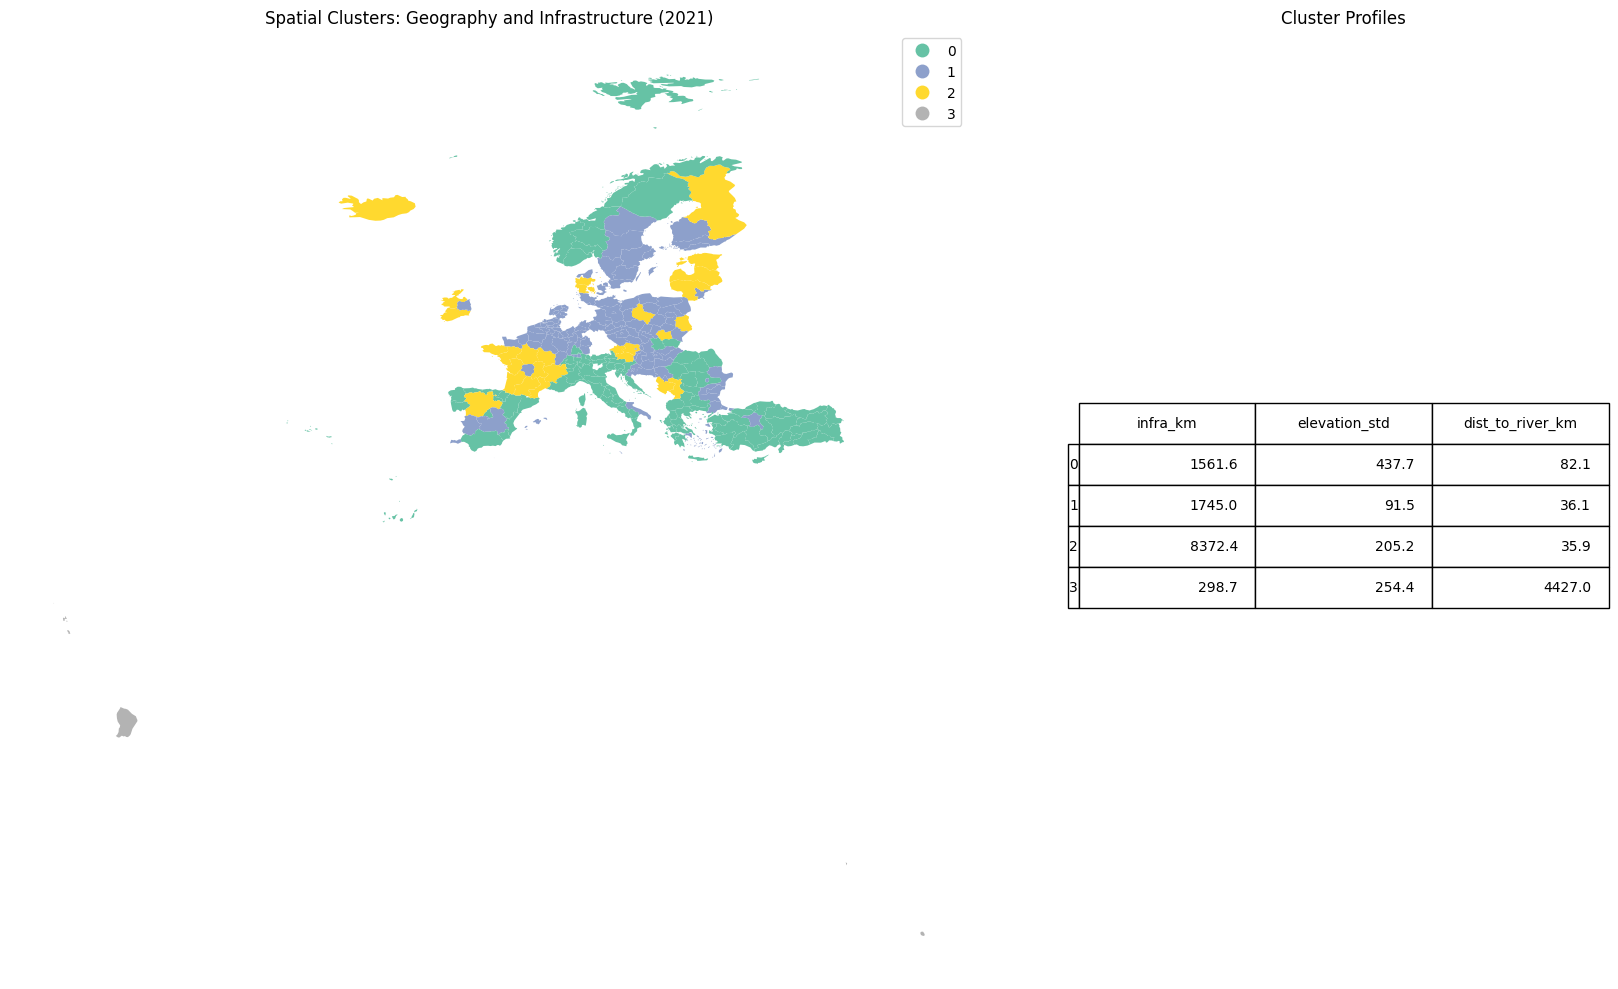

In [41]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(18, 10),
    gridspec_kw={"width_ratios": [3, 1]}
)

# Carte
cluster_map["cluster"] = cluster_map["cluster"].astype(str)
cluster_map.plot(
    column="cluster",
    cmap="Set2",
    legend=True,
    ax=ax1
)

ax1.set_title(
    "Spatial Clusters: Geography and Infrastructure (2021)"
)
ax1.axis("off")

# Tableau
ax2.axis("off")

table = ax2.table(
    cellText=cluster_summary.values,
    colLabels=cluster_summary.columns,
    rowLabels=cluster_summary.index,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2)

ax2.set_title("Cluster Profiles")

plt.tight_layout()
plt.show()

### Indicateur : Clustering spatial des régions NUTS2 (K-Means)

- **Comment c'est calculé :** les régions sont regroupées par `NUTS_ID` et clusterisées avec l'algorithme K-Means. Le clustering repose sur trois variables : `infra_km` (densité des infrastructures), `elevation_std` (rugosité du terrain) et `dist_to_river_km` (distance aux rivières principales).

- **Ce que ça représente :** l'indicateur identifie des groupes de régions partageant des conditions géographiques et des niveaux d'infrastructure similaires.

- **Pourquoi c'est important pour ce projet :** l'objectif est d'étudier si la géographie physique aide à expliquer la distribution des infrastructures dans les régions de l'UE. En combinant les contraintes géographiques et la densité des infrastructures, le clustering met en évidence des profils de développement régional distincts.

- **Visualisation :** chaque couleur représente un cluster généré par l'algorithme K-Means. Les régions appartenant au même cluster présentent des niveaux similaires de densité des infrastructures, de rugosité du terrain et de proximité aux rivières principales.

- **Comment l'interpréter :** les clusters avec une densité d'infrastructure plus faible et des contraintes géographiques plus élevées peuvent indiquer des régions où la géographie physique limite le développement des infrastructures. À l'inverse, les clusters combinant des conditions géographiques favorables avec une haute densité d'infrastructure suggèrent des environnements plus propices au développement des réseaux de transport.

- **Profils des clusters :** le tableau résume les valeurs moyennes de densité des infrastructures, de rugosité du terrain et de proximité aux rivières pour chaque cluster, permettant une interprétation quantitative des profils régionaux identifiés sur la carte.

Le Cluster 2 (jaune) est le groupe à haute densité, avec une moyenne de 8 372 km/1000km²
et concentré près des rivières, visible en Europe centrale occidentale. Le Cluster 3 (gris) est le cas atypique : très faible infrastructure et une distance moyenne aux rivières de 4 427 km, ce qui identifie essentiellement des régions insulaires ou isolées (les Canaries, les Açores, Chypre)
où la variable de proximité aux rivières est géographiquement sans signification plutôt qu'explicative.

## Requête 3-2  Clustering spatial des régions de l'UE

Cette analyse explore si la géographie physique aide à expliquer la distribution des infrastructures de transport dans les régions NUTS2 de l'UE.

Un algorithme de clustering K-Means est appliqué en utilisant deux variables géographiques : la rugosité du terrain (`elevation_std`) et la distance aux rivières principales (`dist_to_river_km`). Ces variables sont utilisées pour identifier des groupes de régions partageant des caractéristiques géographiques similaires.

La densité des infrastructures (`infra_km`) est analysée après le processus de clustering afin d'évaluer si les régions confrontées à des conditions géographiques similaires présentent également des niveaux similaires de développement infrastructurel.

La visualisation résultante combine un Score de Difficulté Géographique, la densité des infrastructures et la densité de population. Cela permet l'étude simultanée des contraintes géographiques, de la distribution des infrastructures de transport et de la concentration démographique dans les régions européennes.

In [ ]:
# Filtrer l'année
sub = master[master["year"] == 2021].copy()

# Supprimer les valeurs manquantes
sub = sub.dropna(
    subset=[
        "infra_km",
        "pop_density",
        "elevation_std",
        "dist_to_river_km"
    ]
)

# Une ligne par région
grouped = sub.groupby(
    ["NUTS_ID", "NUTS_NAME", "country"],
    as_index=False
).agg(
    infra_km=("infra_km", "mean"),
    pop_density=("pop_density", "mean"),
    elevation_std=("elevation_std", "mean"),
    dist_to_river_km=("dist_to_river_km", "mean"),
)

# Clustering KMeans
cluster_features = [
    "elevation_std",
    "dist_to_river_km"
]

scaler = StandardScaler()

X = scaler.fit_transform(
    grouped[cluster_features]
)

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

grouped["cluster"] = kmeans.fit_predict(X)

# Score de difficulté géographique
grouped["difficulty_score"] = X.sum(axis=1)

# Mise à l'échelle de la population
grouped["pop_density_vis"] = np.sqrt(
    grouped["pop_density"]
)

# Visualisation
fig = px.scatter(
    grouped,
    x="difficulty_score",
    y="infra_km",
    color=grouped["cluster"].astype(str),
    size="pop_density_vis",
    size_max=30,
    hover_name="NUTS_ID",
    hover_data=[
        "country",
        "pop_density",
        "elevation_std",
        "dist_to_river_km"
    ],
    labels={
        "difficulty_score": "Geographic Difficulty Score",
        "infra_km": "Infrastructure Density",
        "pop_density": "Population Density",
        "color": "Cluster"
    },
    title="Infrastructure vs Geographic Difficulty (2021)"
)

fig.show()

### Indicateur : Clustering spatial des régions NUTS2 (K-Means)

* **Comment c'est calculé :** les régions sont clusterisées avec K-Means sur deux variables géographiques : la rugosité du terrain (`elevation_std`) et la distance aux rivières principales (`dist_to_river_km`).

* **Ce que ça représente :** l'indicateur identifie des groupes de régions partageant des conditions géographiques similaires.

* **Pourquoi c'est important :** l'objectif est d'évaluer si les contraintes géographiques contribuent à expliquer la distribution des infrastructures dans les régions de l'UE.

* **Visualisation :** l'axe des x représente un Score de Difficulté Géographique dérivé des variables géographiques standardisées, tandis que l'axe des y représente la densité des infrastructures.

* **Comment l'interpréter :** les régions avec une difficulté géographique plus élevée tendent généralement à présenter une densité d'infrastructure plus faible. Cependant, la relation n'est pas systématique. La taille des bulles suggère que la densité de population peut également influencer le développement des infrastructures, car certaines régions densément peuplées maintiennent des niveaux d'infrastructure relativement élevés malgré les contraintes géographiques.

* **Les couleurs** représentent les clusters identifiés par l'algorithme K-Means.

* **La taille des bulles** représente la densité de population (`pop_density`).

## Requête 4 — Tendance temporelle et moyenne mobile [2pt]

**Indicateur** : densité moyenne des infrastructures dans l'UE vs dépenses publiques totales dans le temps, lissée avec une moyenne mobile sur 3 ans.

- **Comment c'est calculé** : les lignes avec des valeurs manquantes pour `year`, `infra_km` ou `expenditure_mEUR` sont supprimées. Les données sont ensuite agrégées par `year` via `groupby().agg()`, calculant la densité moyenne des infrastructures à l'échelle de l'UE et les dépenses totales de transport par année. Une moyenne glissante sur 3 ans (`.rolling(window=3).mean()`) est appliquée à la densité des infrastructures comme feature de lag pour lisser les variations annuelles.
- **Ce que ça représente** : juxtapose le volume d'argent public investi (barres, axe droit) avec les infrastructures physiques disponibles (lignes, axe gauche) dans le temps. La moyenne mobile révèle la tendance à long terme sous-jacente.
- **Comment l'interpréter** : les barres montrent les cycles fiscaux des dépenses publiques de transport. La ligne pleine montre la densité moyenne brute des infrastructures par année. La ligne pointillée est la tendance lissée sur 3 ans. Un décalage entre les pics de dépenses et une ligne pointillée en hausse illustre le temps nécessaire pour que les budgets se traduisent en routes et voies ferrées réelles.

In [ ]:
# ─────────────────────────────────────────────
# Fonction : query4_temporal_forecast
# Entrée :  df (dataframe maître)
# Sortie : Plotly Figure — graphique à double axe : densité moyenne des infrastructures
#          dans l'UE (axe y principal, ligne) et dépenses publiques totales
#          (axe y secondaire, barres), avec une moyenne mobile sur 3 ans superposée
# ─────────────────────────────────────────────
from plotly.subplots import make_subplots
import plotly.graph_objects as go

def query4_temporal_forecast(df):
    sub = df.dropna(subset=['year', 'infra_km', 'expenditure_mEUR']).copy()

    # Agréger à une ligne par année : densité moyenne dans l'UE et dépenses totales
    yearly = sub.groupby('year', as_index=False).agg(
        avg_infra_km=('infra_km', 'mean'),
        total_expenditure=('expenditure_mEUR', 'sum'),
    ).sort_values('year')

    # Moyenne glissante sur 3 ans comme feature de lag pour révéler la tendance à long terme
    yearly['infra_moving_avg_3y'] = yearly['avg_infra_km'].rolling(window=3).mean()

    fig = make_subplots(specs=[[{'secondary_y': True}]])

    # Les barres montrent les cycles fiscaux (axe droit)
    fig.add_trace(
        go.Bar(
            x=yearly['year'], y=yearly['total_expenditure'],
            name='Total Expenditure (mEUR)', opacity=0.5,
        ),
        secondary_y=True,
    )
    # Ligne pleine : densité moyenne brute des infrastructures par année (axe gauche)
    fig.add_trace(
        go.Scatter(
            x=yearly['year'], y=yearly['avg_infra_km'],
            name='Avg Infra Density', mode='lines+markers',
            line=dict(width=2),
        ),
        secondary_y=False,
    )
    # Ligne pointillée : tendance lissée sur 3 ans (axe gauche)
    fig.add_trace(
        go.Scatter(
            x=yearly['year'], y=yearly['infra_moving_avg_3y'],
            name='3-Year Trend (Moving Avg)', mode='lines',
            line=dict(width=3, dash='dash'),
        ),
        secondary_y=False,
    )

    fig.update_layout(
        title='EU Temporal Trend: Infrastructure vs Public Expenditure',
        xaxis_title='Year',
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
        height=500,
    )
    fig.update_yaxes(title_text='Infra Density (km/1000km²)', secondary_y=False)
    fig.update_yaxes(title_text='Total Expenditure (mEUR)', secondary_y=True)
    return fig

In [24]:
# Call Query 4 on the master dataframe and display the result
fig_q4 = query4_temporal_forecast(master)
fig_q4.show()

#### Observations clés

**1990 à 1996.** La ligne de densité fluctue fortement, et la lecture honnête est un
artefact de couverture des données : moins de régions NUTS2 rapportent dans les premières années,
donc la moyenne est calculée sur un échantillon mince et changeant.

**1997 à 2012.** La densité se stabilise autour de 3 300 à 3 600 km/1000km² tandis que
les dépenses augmentent régulièrement d'environ 1,5 Mrd à 4 Mrd d'EUR. Les dépenses augmentent
mais le réseau moyen ne s'étend pas, ce qui suggère que les régions de l'UE occidentale
étaient déjà denses et que le nouvel argent allait à la maintenance.

**2013 à 2015.** La densité chute brusquement d'environ 3 450 à environ 2 700
km/1000km², coïncidant avec les révisions des frontières NUTS2 qui ont introduit de nouvelles
régions à faible densité dans le panel et tiré la moyenne vers le bas. C'est très
certainement un artefact méthodologique plutôt qu'un événement infrastructurel réel.

**2015 à 2024.** Les dépenses s'accélèrent à près de 12 Mrd d'EUR tandis que la densité
se stabilise autour de 2 600 à 2 800 km/1000km². Les deux sont, essentiellement, découplés,
et c'est ce que ce graphique montre de plus utile : les dépenses publiques seules
ne permettent pas de prédire où atterrit la densité des infrastructures, ce qui est,
en définitive, pourquoi les facteurs spatiaux et écologiques examinés dans les requêtes
précédentes ont un réel pouvoir explicatif.